# Notebook 4: Model Training & Evaluation

**Capstone Project — IIoT Edge Computing Predictive Maintenance**

This notebook covers:
- **Task 5**: Train at least two ML models and evaluate using appropriate metrics
- **Task 6**: Interpretation and discussion
  - Identify best-performing pipeline
  - Discuss precision vs recall trade-offs
  - Practical implications of misclassification
  - Limitations and future work

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Load Data and Feature Sets

In [2]:
# Load processed data
df = pd.read_csv('processed_iiot_edge.csv')

# Load selected features from Notebook 3
with open('selected_features.json', 'r') as f:
    feature_sets = json.load(f)

rfe_features = feature_sets['rfe_features']
chi2_features = feature_sets['chi2_features']
pca_n_components = feature_sets['pca_n_components']

print(f"Dataset shape: {df.shape}")
print(f"RFE features: {len(rfe_features)}")
print(f"Chi2 features: {len(chi2_features)}")
print(f"PCA components: {pca_n_components}")

Dataset shape: (1000, 9)
RFE features: 5
Chi2 features: 5
PCA components: 8


In [5]:
# Prepare data

X = df.drop(['Predicted_Failure'], axis=1)
y = df['Predicted_Failure']
label_names = df['Predicted_Failure'].unique()

# Train-test split (consistent with previous notebooks)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training: {X_train.shape}, Test: {X_test.shape}")

Training: (800, 8), Test: (200, 8)


## 2. Prepare Feature Sets and Sampling Strategies

We will cross-evaluate models across:
- **Sampling**: Original (no resampling) vs. SMOTE vs. SMOTETomek
- **Features**: RFE-selected features (best from Notebook 3)

In [6]:
# Use RFE features (best performing from Notebook 3)
X_train_fs = X_train[rfe_features]
X_test_fs = X_test[rfe_features]

print(f"Using RFE features: {X_train_fs.shape[1]} features")

# Prepare sampling variants
print("\nPreparing sampling variants...")

# Original
datasets = {
    'Original': (X_train_fs, y_train)
}

# SMOTE
print("  Applying SMOTE...")
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_fs, y_train)
datasets['SMOTE'] = (X_smote, y_smote)

# SMOTETomek
print("  Applying SMOTETomek...")
smotetomek = SMOTETomek(random_state=42)
X_st, y_st = smotetomek.fit_resample(X_train_fs, y_train)
datasets['SMOTETomek'] = (X_st, y_st)

for name, (X_s, y_s) in datasets.items():
    print(f"  {name}: {X_s.shape[0]:,} samples")

Using RFE features: 5 features

Preparing sampling variants...
  Applying SMOTE...
  Applying SMOTETomek...
  Original: 800 samples
  SMOTE: 874 samples
  SMOTETomek: 850 samples


## 3. Define Models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, multi_class='multinomial', solver='lbfgs', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, random_state=42, n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=20, random_state=42
    )
}

# Optional: XGBoost if installed
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=42, n_jobs=-1,
        use_label_encoder=False
    )
    print("XGBoost available — included in evaluation.")
except ImportError:
    print("XGBoost not installed — proceeding with 3 models.")
    print("Install with: pip install xgboost")

print(f"\nModels to evaluate: {list(models.keys())}")

XGBoost available — included in evaluation.

Models to evaluate: ['Logistic Regression', 'Random Forest', 'Decision Tree', 'XGBoost']


## 4. Train and Evaluate All Combinations

In [8]:
all_results = []

for sampling_name, (X_s, y_s) in datasets.items():
    for model_name, model in models.items():
        print(f"Training {model_name} on {sampling_name} data...", end=' ')
        
        # Clone model to avoid state leakage
        from sklearn.base import clone
        m = clone(model)
        m.fit(X_s, y_s)
        y_pred = m.predict(X_test_fs)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        
        all_results.append({
            'Sampling': sampling_name,
            'Model': model_name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4)
        })
        
        print(f"Acc={acc:.4f}, F1={f1:.4f}")

results_df = pd.DataFrame(all_results)
print("\n=== Full Results ===")
results_df

Training Logistic Regression on Original data... Acc=0.8600, F1=0.8580
Training Random Forest on Original data... Acc=1.0000, F1=1.0000
Training Decision Tree on Original data... Acc=1.0000, F1=1.0000
Training XGBoost on Original data... Acc=1.0000, F1=1.0000
Training Logistic Regression on SMOTE data... Acc=0.8550, F1=0.8531
Training Random Forest on SMOTE data... Acc=1.0000, F1=1.0000
Training Decision Tree on SMOTE data... Acc=1.0000, F1=1.0000
Training XGBoost on SMOTE data... Acc=1.0000, F1=1.0000
Training Logistic Regression on SMOTETomek data... Acc=0.8550, F1=0.8531
Training Random Forest on SMOTETomek data... Acc=1.0000, F1=1.0000
Training Decision Tree on SMOTETomek data... Acc=1.0000, F1=1.0000
Training XGBoost on SMOTETomek data... Acc=1.0000, F1=1.0000

=== Full Results ===


,Sampling,Model,Accuracy,Precision,Recall,F1-Score
0,Original,Logistic Regression,0.860,0.8614,0.8561,0.8580
1,Original,Random Forest,1.000,1.0000,1.0000,1.0000
2,Original,Decision Tree,1.000,1.0000,1.0000,1.0000
3,Original,XGBoost,1.000,1.0000,1.0000,1.0000
4,SMOTE,Logistic Regression,0.855,0.8557,0.8515,0.8531
5,SMOTE,Random Forest,1.000,1.0000,1.0000,1.0000
6,SMOTE,Decision Tree,1.000,1.0000,1.0000,1.0000
7,SMOTE,XGBoost,1.000,1.0000,1.0000,1.0000
8,SMOTETomek,Logistic Regression,0.855,0.8557,0.8515,0.8531
9,SMOTETomek,Random Forest,1.000,1.0000,1.0000,1.0000


## 5. Results Visualization

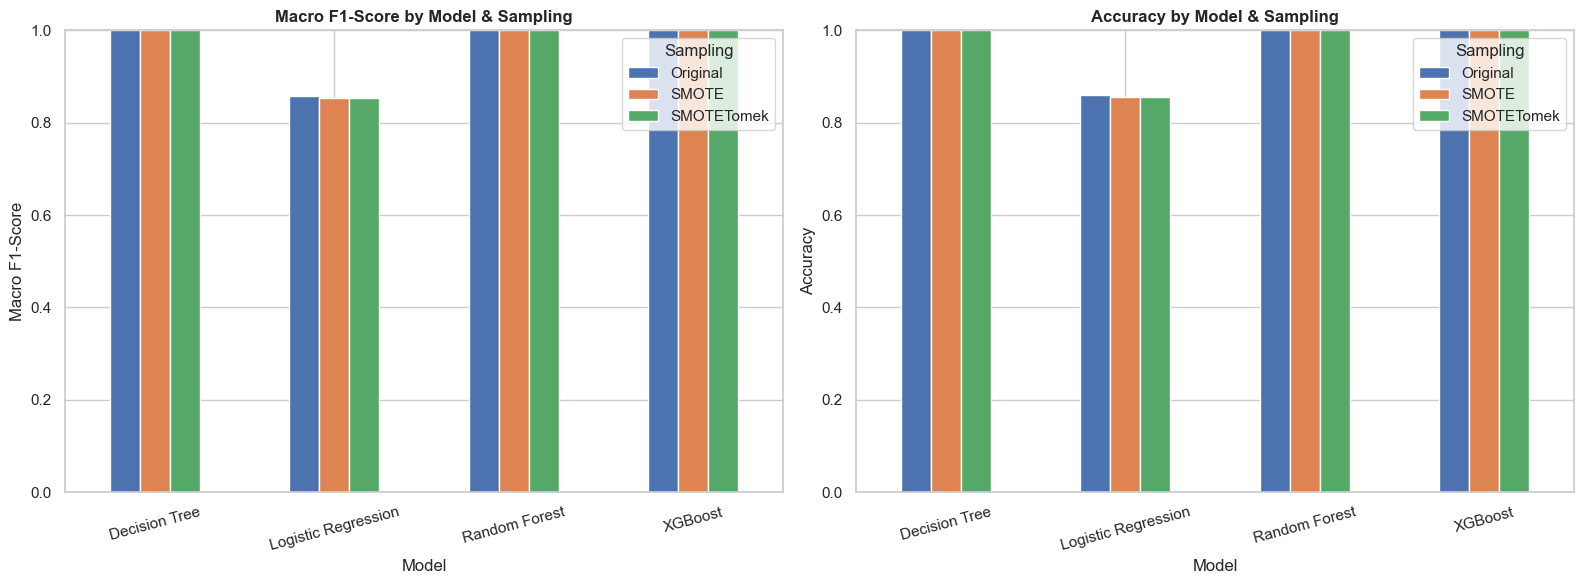

In [17]:
# Grouped bar chart — F1-Score by Model and Sampling Strategy
pivot_f1 = results_df.pivot(index='Model', columns='Sampling', values='F1-Score')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_f1.plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('Macro F1-Score by Model & Sampling', fontweight='bold')
axes[0].set_ylabel('Macro F1-Score')
axes[0].legend(title='Sampling')
axes[0].set_ylim(0, 1)

pivot_acc = results_df.pivot(index='Model', columns='Sampling', values='Accuracy')
pivot_acc.plot(kind='bar', ax=axes[1], rot=15)
axes[1].set_title('Accuracy by Model & Sampling', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].legend(title='Sampling')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Best Model — Detailed Evaluation

In [10]:
# Identify best model
best_row = results_df.loc[results_df['F1-Score'].idxmax()]
print("=== Best Performing Pipeline ===")
print(f"Model:    {best_row['Model']}")
print(f"Sampling: {best_row['Sampling']}")
print(f"Accuracy: {best_row['Accuracy']}")
print(f"F1-Score: {best_row['F1-Score']}")

=== Best Performing Pipeline ===
Model:    Random Forest
Sampling: Original
Accuracy: 1.0
F1-Score: 1.0


In [11]:
# Re-train the best model for detailed analysis
best_sampling = best_row['Sampling']
best_model_name = best_row['Model']

X_best, y_best = datasets[best_sampling]
best_model = clone(models[best_model_name])
best_model.fit(X_best, y_best)
y_pred_best = best_model.predict(X_test_fs)

# Full classification report
print(f"\n--- Classification Report ({best_model_name} + {best_sampling}) ---")
print(classification_report(y_test, y_pred_best))


--- Classification Report (Random Forest + Original) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        91

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



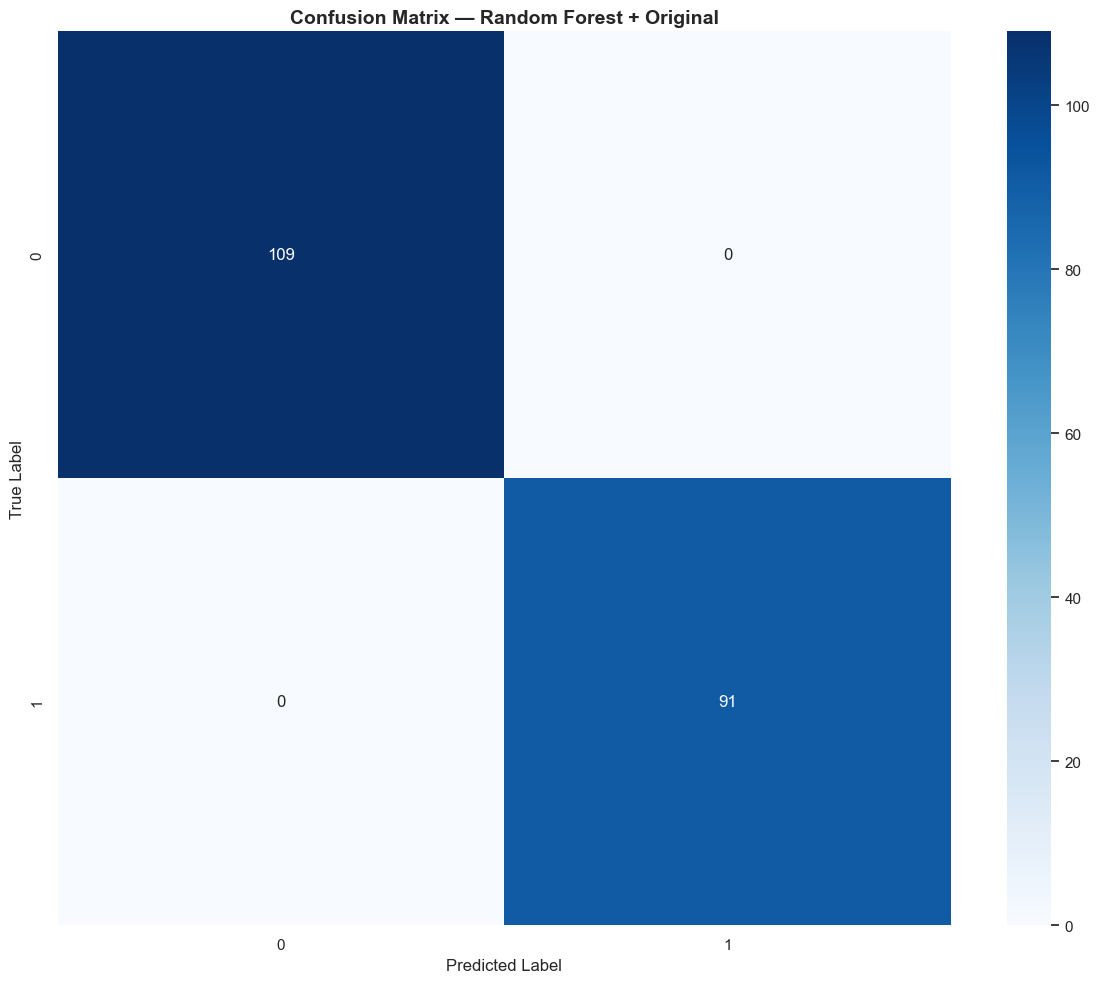

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix — {best_model_name} + {best_sampling}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance (Best Model)

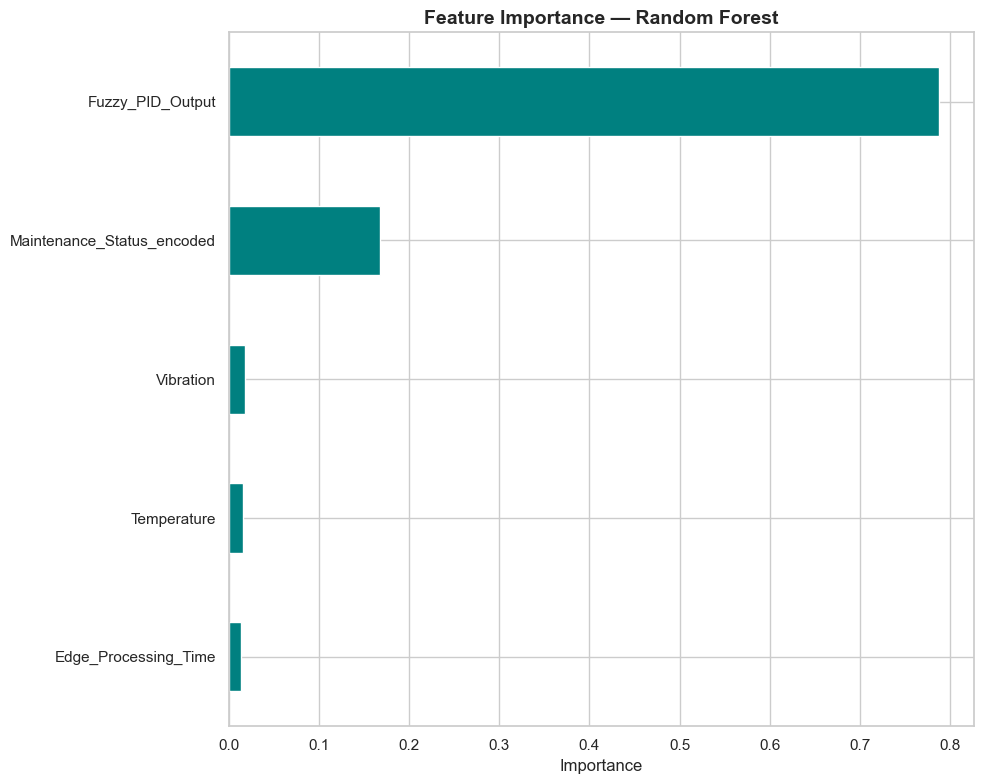


Top 10 Most Important Features:
Fuzzy_PID_Output              0.787602
Maintenance_Status_encoded    0.166962
Vibration                     0.017203
Temperature                   0.015086
Edge_Processing_Time          0.013147
dtype: float64


In [20]:
# Feature importance (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=rfe_features)
    importances_sorted = importances.sort_values(ascending=True)
    
    plt.figure(figsize=(10, 8))
    importances_sorted.plot(kind='barh', color='teal')
    plt.title(f'Feature Importance — {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(importances.sort_values(ascending=False).head(10))
else:
    print("Feature importance not available for this model type.")

## 8. Precision-Recall Trade-off Analysis

In [14]:
# Per-class precision and recall
from sklearn.metrics import precision_recall_fscore_support

prec_per_class, rec_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_test, y_pred_best
)

pr_df = pd.DataFrame({
    'Class': sorted(y.unique()),
    'Precision': np.round(prec_per_class, 4),
    'Recall': np.round(rec_per_class, 4),
    'F1-Score': np.round(f1_per_class, 4),
    'Support': support
})

print("Per-Class Metrics:")
print(pr_df.to_string(index=False))

Per-Class Metrics:
 Class  Precision  Recall  F1-Score  Support
     0        1.0     1.0       1.0      109
     1        1.0     1.0       1.0       91


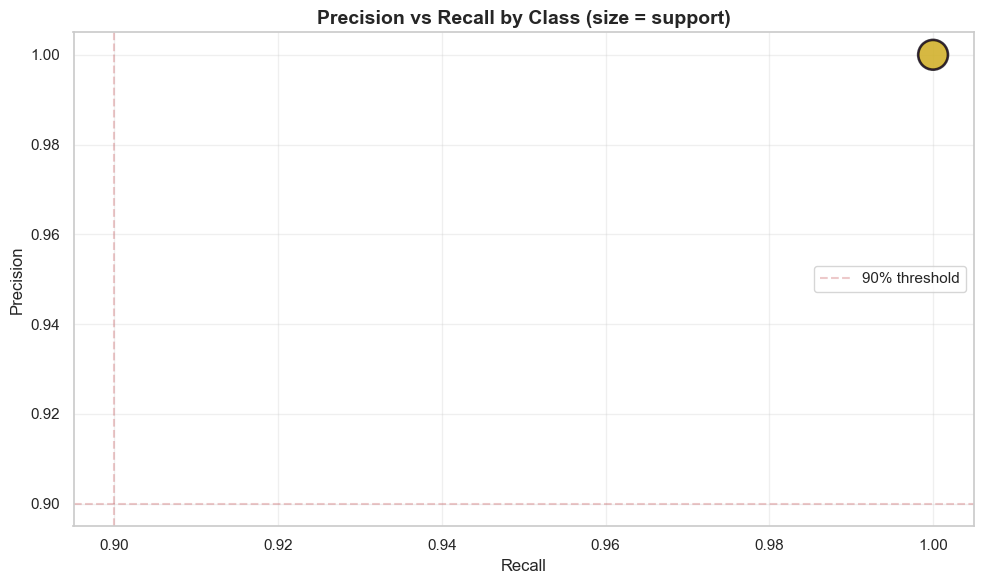

In [21]:
# Precision vs Recall scatter
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pr_df['Recall'], pr_df['Precision'], 
                      s=pr_df['Support'] / pr_df['Support'].max() * 500,
                      alpha=0.7, c=range(len(pr_df)), cmap='viridis', edgecolors='black')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision vs Recall by Class (size = support)', fontsize=14, fontweight='bold')
plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.3, label='90% threshold')
plt.axvline(x=0.9, color='r', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

### Practical Implications of Misclassification

In predictive maintenance for industrial IoT systems:

| Error Type | Impact | Cost Level |
|---|---|---|
| False Negative (missed failure) | Equipment fails unexpectedly, causing downtime, safety hazards, and expensive emergency repairs | **Very High** |
| False Positive (false alarm) | Unnecessary preventive maintenance, wasted resources | Moderate |

**Conclusion**: High recall is critical — missing a failure prediction can lead to catastrophic equipment failure, production downtime, and safety incidents. A false alarm is preferable to a missed failure.

## 9. Summary Results Table

In [16]:
# Final summary
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"\nDataset: IoT Intrusion Detection ({df.shape[0]:,} records)")
print(f"Features: {len(rfe_features)} (RFE-selected)")
print(f"Classes: {y.nunique()} attack types")
print(f"\nBest Pipeline:")
print(f"  Model:    {best_row['Model']}")
print(f"  Sampling: {best_row['Sampling']}")
print(f"  Features: RFE ({len(rfe_features)} features)")
print(f"  Accuracy: {best_row['Accuracy']}")
print(f"  F1-Score: {best_row['F1-Score']}")
print("\n" + "="*60)

# Full comparison
print("\nAll Results:")
print(results_df.sort_values('F1-Score', ascending=False).to_string(index=False))


FINAL RESULTS SUMMARY

Dataset: IoT Intrusion Detection (1,000 records)
Features: 5 (RFE-selected)
Classes: 2 attack types

Best Pipeline:
  Model:    Random Forest
  Sampling: Original
  Features: RFE (5 features)
  Accuracy: 1.0
  F1-Score: 1.0


All Results:
  Sampling               Model  Accuracy  Precision  Recall  F1-Score
  Original       Random Forest     1.000     1.0000  1.0000    1.0000
  Original       Decision Tree     1.000     1.0000  1.0000    1.0000
  Original             XGBoost     1.000     1.0000  1.0000    1.0000
     SMOTE       Random Forest     1.000     1.0000  1.0000    1.0000
SMOTETomek             XGBoost     1.000     1.0000  1.0000    1.0000
     SMOTE       Decision Tree     1.000     1.0000  1.0000    1.0000
     SMOTE             XGBoost     1.000     1.0000  1.0000    1.0000
SMOTETomek       Random Forest     1.000     1.0000  1.0000    1.0000
SMOTETomek       Decision Tree     1.000     1.0000  1.0000    1.0000
  Original Logistic Regression     0.